In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [3]:
# Load the dataset
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [40]:
print("Dataset shape: ", df.shape)

Dataset shape:  (2640, 13)


In [38]:
print("\nDataset Info:", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   object        
 11  Charging_Stations     2640 non-null   int64         
 12  Date                  2640 non-null   datetime64[ns]
dtypes: datetime64[ns](

In [6]:
print("Summary:", df.describe())

Summary:               Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min     50003.7

In [27]:
print("\nMissing values:", df.isnull().sum())


Missing values: Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64


##  Data Preprocessing
Here we will:

 Combine Year and month into a datetime column.

 Sort the dataset.

 Handle any missing values.


In [28]:
# Create a datetime column from Year and Month
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

In [29]:
# Sort values by Date
df = df.sort_values('Date').reset_index(drop=True)

In [30]:
# Drop duplicates
df = df.drop_duplicates()

In [31]:
# Check for missing values
if df.isnull().sum().any():
    print("Missing values found")
    df = df.fillna(method='ffill')

df[['Date', 'Region', 'Model', 'Estimated_Deliveries']].head()

,Date,Region,Model,Estimated_Deliveries
0,2015-01-01,Asia,Model Y,12446
1,2015-01-01,Middle East,Model Y,10348
2,2015-01-01,Europe,Model Y,10835
3,2015-01-01,North America,Model Y,12170
4,2015-01-01,Europe,Model 3,7597


## Exploratory Data Analysis (EDA)
Here we will explore distribution of target variables, correlations, and temporal trends.


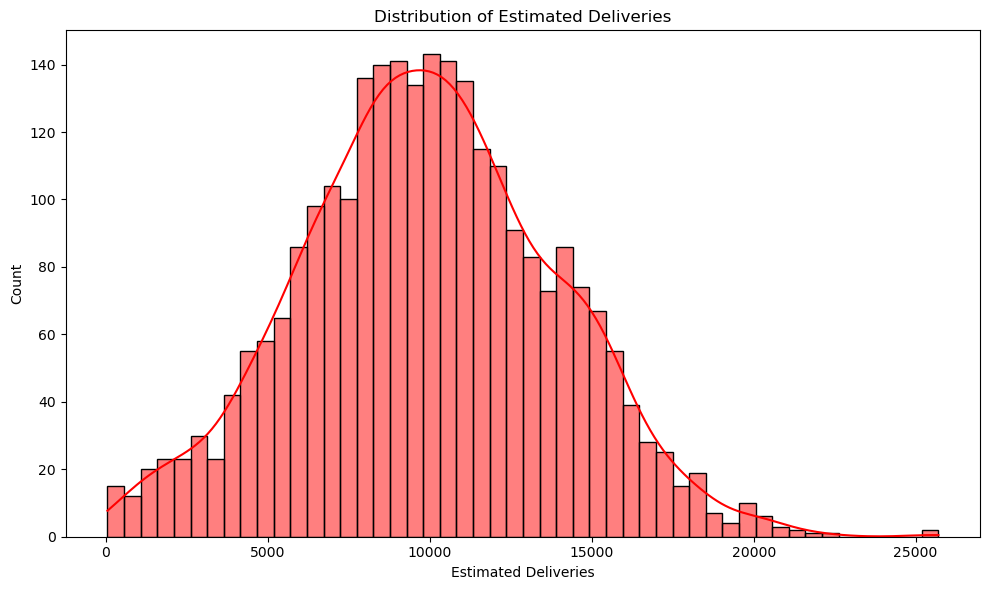

In [12]:
# Univariate Analysis: Distribution of Estimated Deliveries
plt.figure(figsize=(10, 6))
sns.histplot(df['Estimated_Deliveries'], bins=50, kde=True, color='red')
plt.title('Distribution of Estimated Deliveries')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


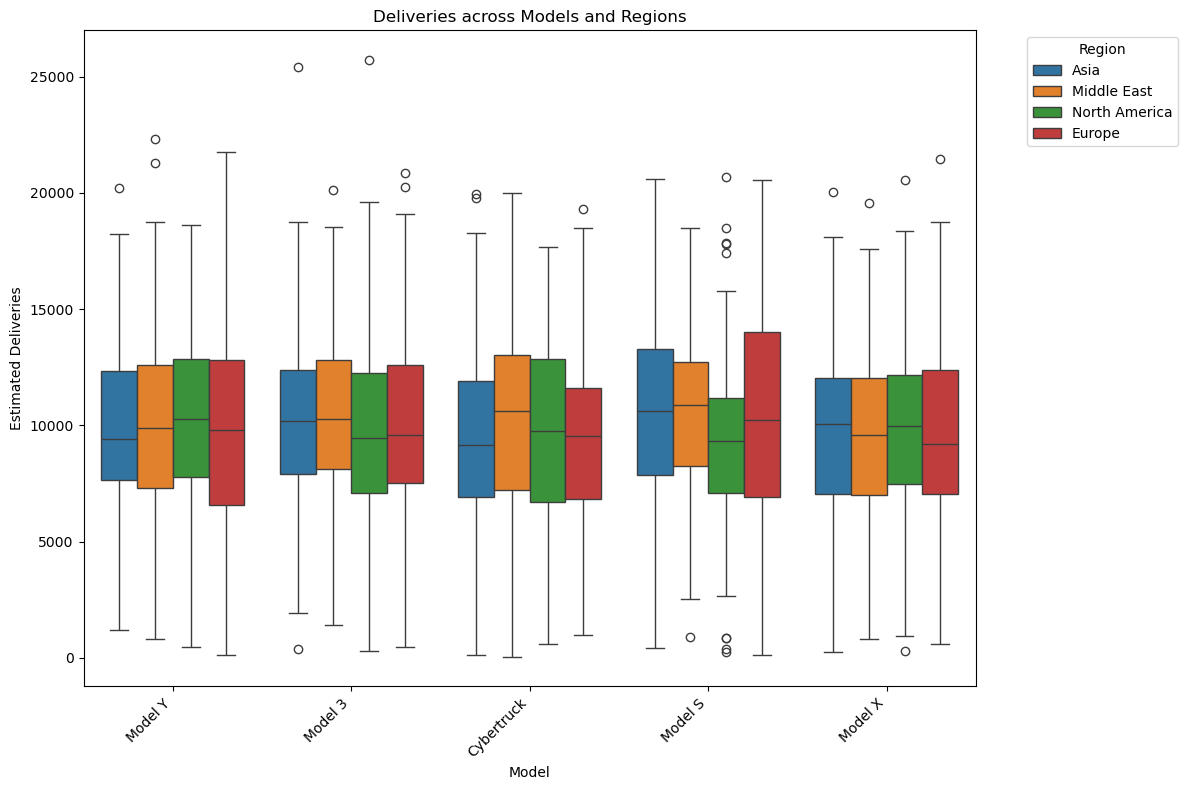

In [13]:
# Bivariate Analysis: Deliveries by Region and Model
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Model', y='Estimated_Deliveries', hue='Region')
plt.title('Deliveries across Models and Regions')
plt.xlabel('Model')
plt.ylabel('Estimated Deliveries')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


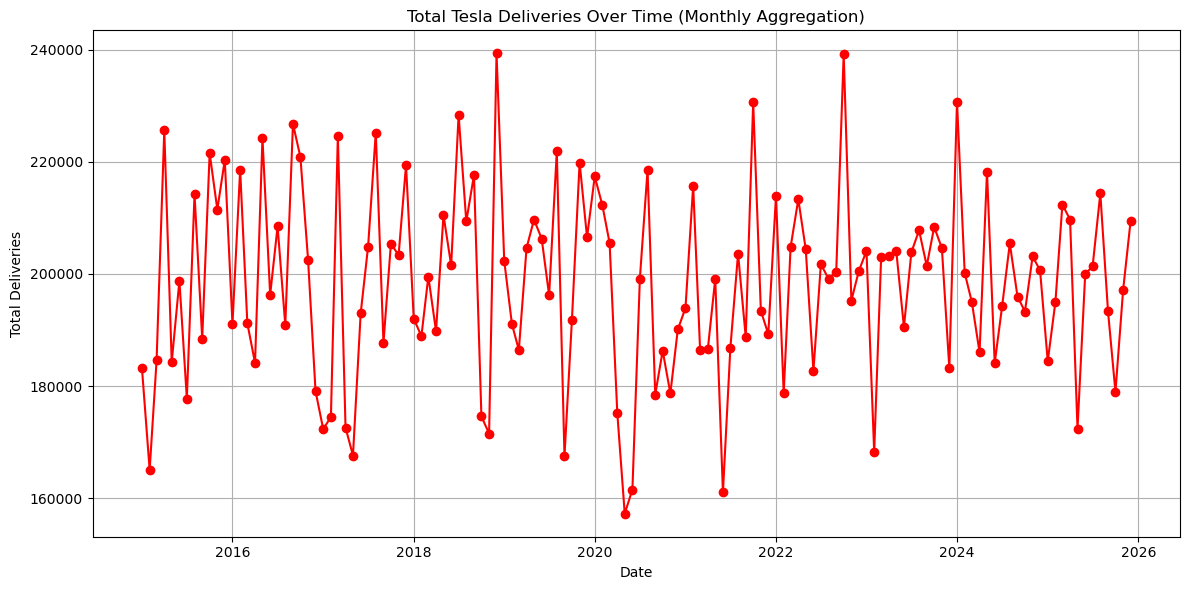

In [14]:
# Temporal Trends: Overall Deliveries Over Time
monthly_deliveries = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_deliveries['Date'], monthly_deliveries['Estimated_Deliveries'], marker='o', color='red')
plt.title('Total Tesla Deliveries Over Time (Monthly Aggregation)')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.grid(True)
plt.tight_layout()
plt.show()


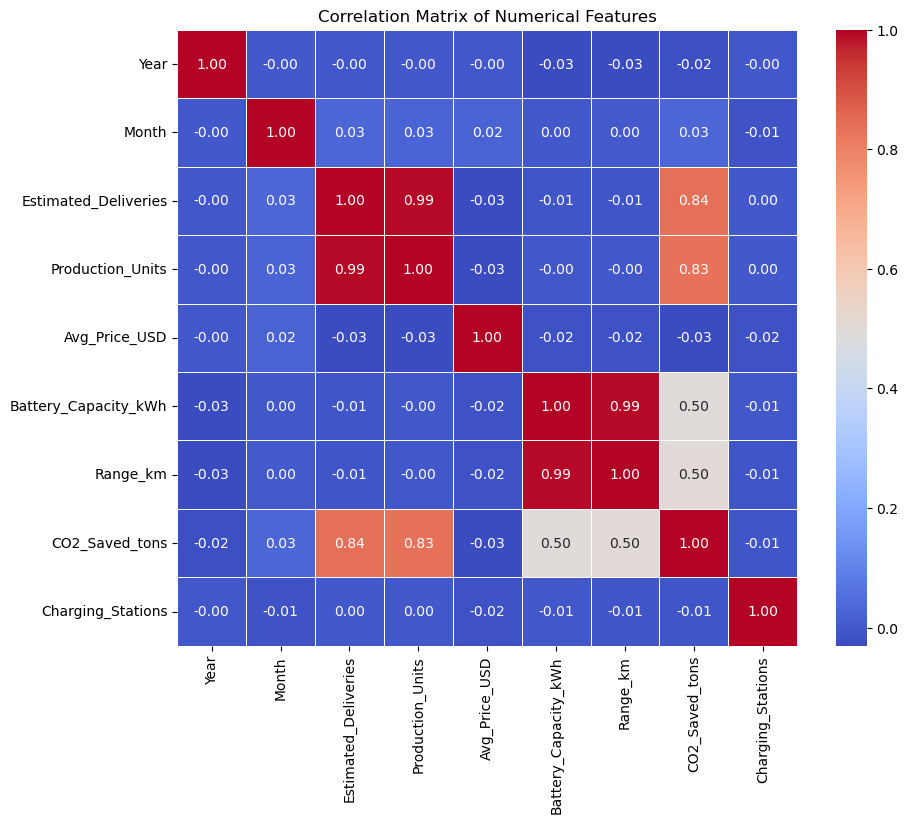

In [15]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


## Feature Engineering
We will enrich the dataset by:
- Adding temporal features (Quarter, Season).
- Creating lag features (previous month deliveries).
- Rolling averages to capture trend momentum.


In [16]:
# Temporal Features
df_fe = df.copy()
df_fe['Quarter'] = df_fe['Date'].dt.quarter
df_fe['Season'] = df_fe['Month'].apply(lambda x: (x%12 + 3)//3) # 1: Winter, 2: Spring, 3: Summer, 4: Fall

print(df_fe[['Date', 'Quarter', 'Season']].sample(5))

           Date  Quarter  Season
1949 2023-02-01        1       1
2578 2025-09-01        3       4
2203 2024-03-01        1       2
2327 2024-09-01        3       4
2011 2023-05-01        2       2


In [17]:
df_fe = df_fe.sort_values(by=['Region', 'Model', 'Date'])

# Create Lag 1 and Lag 3 features (previous month and 3 months ago deliveries for the same region and model)
df_fe['Lag_1_Deliveries'] = df_fe.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df_fe['Lag_3_Deliveries'] = df_fe.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(3)


In [32]:
# Rolling 3-month average
df_fe['Rolling_3M_Deliveries'] = df_fe.groupby(['Region', 'Model'])['Estimated_Deliveries'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Drop rows with NaN from shifting
df_fe = df_fe.dropna().reset_index(drop=True)

print(df_fe[['Date', 'Region', 'Model', 'Estimated_Deliveries', 'Lag_1_Deliveries', 'Rolling_3M_Deliveries']].head())


        Date Region       Model  Estimated_Deliveries  Lag_1_Deliveries  \
0 2015-04-01   Asia  Cybertruck                 15221           10257.0   
1 2015-05-01   Asia  Cybertruck                  6406           15221.0   
2 2015-06-01   Asia  Cybertruck                  7201            6406.0   
3 2015-07-01   Asia  Cybertruck                   113            7201.0   
4 2015-08-01   Asia  Cybertruck                 10222             113.0   

   Rolling_3M_Deliveries  
0           15221.000000  
1           10813.500000  
2            9609.333333  
3            4573.333333  
4            5845.333333  


## Regression Modeling
Target Variable: Estimated_Deliveries


In [19]:
# Prepare features and target
features = ['Year', 'Month', 'Quarter', 'Season', 'Battery_Capacity_kWh', 'Range_km', 
            'Avg_Price_USD', 'Lag_1_Deliveries', 'Rolling_3M_Deliveries', 'Region', 'Model', 'Source_Type']
target = 'Estimated_Deliveries'

X = df_fe.drop(columns=['Estimated_Deliveries'],axis=1)
y = df_fe['Estimated_Deliveries']

# Time-based Train-Test Split (e.g., test on 2024-2025 data)
# Let's find the split point (last 15% of data chronologically)
split_idx = int(len(df_fe) * 0.85)

# Sort by date before splitting
df_fe_sorted = df_fe.sort_values('Date')
X = df_fe_sorted[features]
y = df_fe_sorted[target]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")


Training shape: (2193, 12)
Testing shape: (387, 12)


In [20]:
# Preprocessing Pipeline (Encoding and Scaling)
numeric_features = ['Year', 'Month', 'Quarter', 'Season', 'Battery_Capacity_kWh', 'Range_km', 
                    'Avg_Price_USD', 'Lag_1_Deliveries', 'Rolling_3M_Deliveries']
categorical_features = ['Region', 'Model', 'Source_Type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42)
}

# Train and Evaluate Models
results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_df = pd.DataFrame(results).T
display(results_df)


,MAE,RMSE,R2
Linear Regression,2149.342286,2693.530609,0.465060
Ridge Regression,2149.174695,2693.257383,0.465169
Lasso Regression,2148.136656,2691.941369,0.465691


## Hyperparameter Tuning
We will use RandomizedSearchCV on the Ridge model to find better hyperparameters.


In [21]:
# Tuning Ridge
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', Ridge(random_state=42))])

param_distributions = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]
}



In [22]:
tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(ridge_pipeline, param_distributions, n_iter=6, 
cv=tscv, scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1, verbose=1)

random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")

# Evaluate best model
best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"Tuned Ridge MAE: {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"Tuned Ridge R2: {r2_score(y_test, y_pred_best):.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'regressor__alpha': 0.1}
Tuned Ridge MAE: 2149.32
Tuned Ridge R2: 0.4651


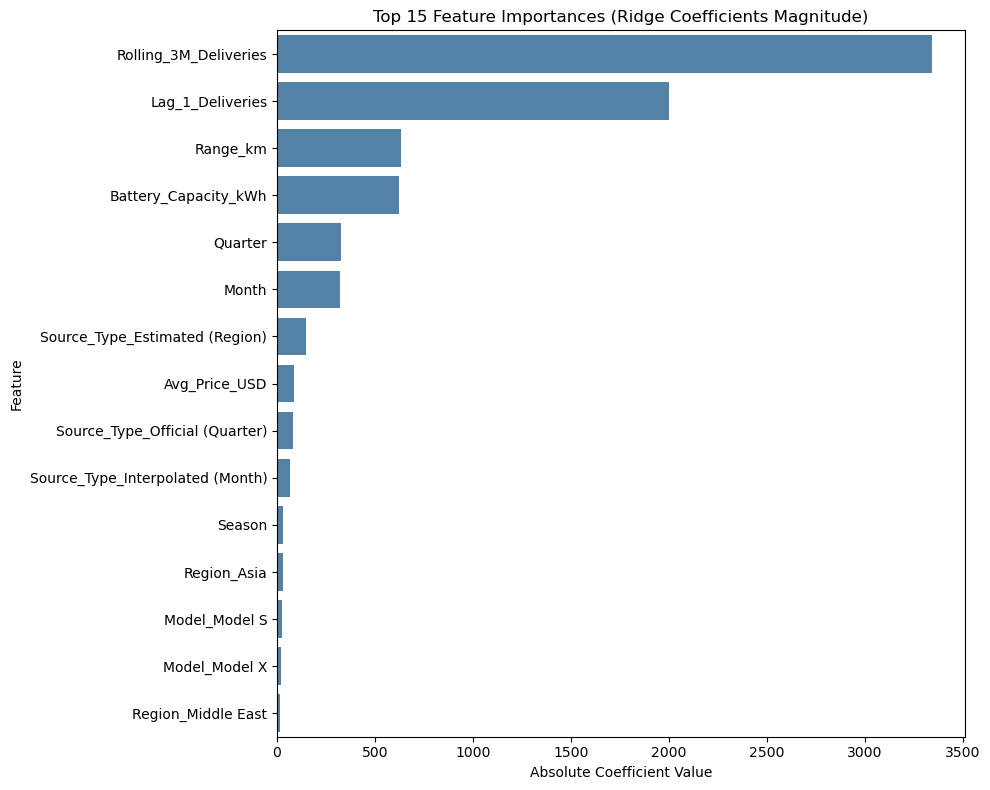

In [23]:
prep = best_model.named_steps['preprocessor']
ridge_reg = best_model.named_steps['regressor']

cat_features_encoded = prep.transformers_[1][1].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_features_encoded)

# Plot feature importance
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': np.abs(ridge_reg.coef_)
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='steelblue')
plt.title('Top 15 Feature Importances (Ridge Coefficients Magnitude)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Time Series Forecasting
We will aggregate deliveries globally by month, test stationarity using ADFuller, and forecast future deliveries using Exponential Smoothing.


In [24]:
# Prepare data for Exponential Smoothing
monthly_deliveries = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
ts = monthly_deliveries.set_index('Date')['Estimated_Deliveries'].asfreq('MS')

# Stationarity test
adf_result = adfuller(ts)
print(f"ADF Statistic: {adf_result[0]:.5f}")
print(f"p-value: {adf_result[1]:.5f}")



ADF Statistic: -8.88099
p-value: 0.00000


In [25]:
for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value:.5f}")

if adf_result[1] <= 0.05:
    print("Series appears stationary.")
else:
    print("Series is non-stationary; Exponential Smoothing can still provide a trend+seasonal forecast.")

Critical Value (1%): -3.48168
Critical Value (5%): -2.88404
Critical Value (10%): -2.57877
Series appears stationary.


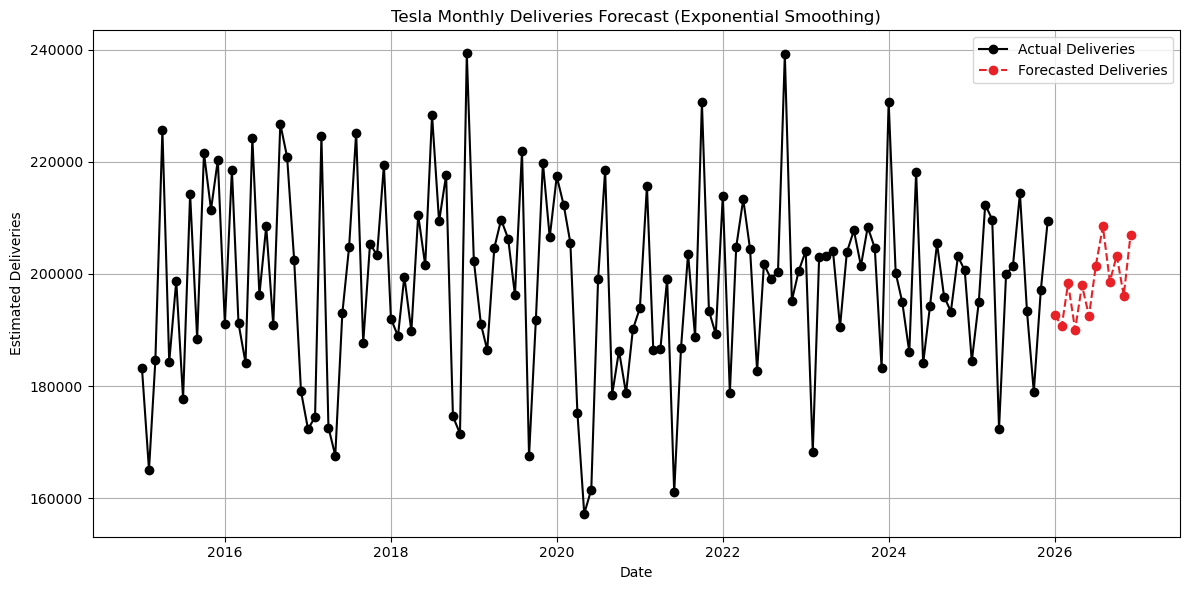

In [26]:
# Fit Exponential Smoothing model
model = ExponentialSmoothing(ts, trend="add", seasonal="add", seasonal_periods=12)
hw_fit = model.fit(optimized=True)

forecast_periods = 12
forecast_index = pd.date_range(start=ts.index[-1] + pd.offsets.MonthBegin(1), periods=forecast_periods, freq='MS')
forecast = pd.Series(hw_fit.forecast(forecast_periods), index=forecast_index)

plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts, label='Actual Deliveries', marker='o', color='black')
plt.plot(forecast.index, forecast, label='Forecasted Deliveries', marker='o', linestyle='--', color='#e82127')
plt.title('Tesla Monthly Deliveries Forecast (Exponential Smoothing)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusion

The analysis shows that Tesla deliveries are strongly influenced by historical sales patterns, regional demand, and product characteristics. Feature engineering using lag variables and rolling averages significantly improved predictive performance. Ridge Regression provided robust delivery predictions, while Exponential Smoothing successfully captured long-term trends and seasonality to forecast the next 12 months of Tesla deliveries.